##Imports

In [ ]:
import pandas as pd
import nltk
from nltk.probability import FreqDist
from textblob import TextBlob, Word
from collections import Counter
from gensim.models import Word2Vec
from itertools import product
import gensim.downloader as api
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from nltk.util import ngrams
from nltk.corpus import wordnet as wn
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
nltk.download('punkt')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

###Load transformer models

In [ ]:
!pip install einops

In [ ]:
from transformers import AutoModelForSequenceClassification
model = AutoModelForSequenceClassification.from_pretrained(
  "togethercomputer/m2-bert-80M-2k-retrieval",
  trust_remote_code=True
)
model_name = "togethercomputer/m2-bert-80M-2k-retrieval"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

You are using a model of type m2_bert to instantiate a model of type bert. This is not supported for all configurations of models and can yield errors.


-- Bidirectional: True
-- Using Long Conv Residual: True
-- Hyena w: 10
-- Hyena w mod: 1
-- Hyena filter order: 128
-- Hyena filter dropout: 0.2
-- Hyena filter wd: 0.1
-- Hyena filter emb dim: 5
-- Hyena filter lr: 0.001
-- Hyena filter lr pos emb: 1e-05
The repository for togethercomputer/m2-bert-80M-2k-retrieval contains custom code which must be executed to correctly load the model. You can inspect the repository content at https://hf.co/togethercomputer/m2-bert-80M-2k-retrieval.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y


You are using a model of type m2_bert to instantiate a model of type bert. This is not supported for all configurations of models and can yield errors.


-- Bidirectional: True
-- Using Long Conv Residual: True
-- Hyena w: 10
-- Hyena w mod: 1
-- Hyena filter order: 128
-- Hyena filter dropout: 0.2
-- Hyena filter wd: 0.1
-- Hyena filter emb dim: 5
-- Hyena filter lr: 0.001
-- Hyena filter lr pos emb: 1e-05


##Assets

In [ ]:
def preprocessing(data,field):
  data["LEMMAS"] = data[field].apply(lambda x: ' '.join([Word(word).lemmatize() for word in x.split()]))

In [ ]:
import math
def MAE_Scoring(calculated,expected):
  mae=0
  for calc, exp in zip(calculated, expected):
        if not math.isnan(calc):
          mae += abs(calc - exp)
        else:
          print('nan')
  return mae / (len(calculated))

In [ ]:
def evaluateApproach(calculated, expected):

  relation_dataset_sorted=relations_undersampled.sort_values(by='PID')
  query_id_list=queries_undersampled['ID']
  for qid in query_id_list:
      # Find the 1st row where query-id = qid (step 300 because each 300 consecutive has the same qid)
      first_row_index = relation_dataset_sorted.index[relation_dataset_sorted['PID'] == qid][0]

      # Bring doc_id where score >= 2
      dic1 = relation_dataset_sorted.loc[first_row_index:first_row_index+299][relation_dataset_sorted[score] >= 2]['DocID'].tolist()

      # Bring doc_id where expected >= 2
      lst = relation_dataset_sorted.loc[first_row_index:first_row_index+299][relation_dataset_sorted['expected'] >= 2]['Doc_id'].tolist()

      # Top 5 doc_id based on score if exist from dic1
      t_5 = [doc_id for doc_id in dic1[:5]] if dic1 else []

      # Find intersection between t_5 and lst
      intersection = list(set(t_5) & set(lst))

      return intersection/len(set(t_5))

##Data preprocessing

In [ ]:
queries_undersampled = pd.read_csv('/content/drive/MyDrive/NLP/QueriesUndersampled.csv')
documents_undersampled=pd.read_csv('/content/drive/MyDrive/NLP/DocuentsUndersampled.csv')
relations_undersampled=pd.read_csv('/content/drive/MyDrive/NLP/RelationsUndersampled_150.csv')

In [ ]:
#add zeros
# querIds=queries_undersampled['PID']
# docIds=documents_undersampled['ID']
# for qid in querIds:
#   for did in docIds:
#     index_of_row = relations_undersampled.loc[(relations_undersampled['PID'] == qid) & (relations_undersampled['DocID'] == did)].index
#     if index_of_row.empty:
#       relations_undersampled.loc[len(relations_undersampled)] = [qid, did, 0]

In [ ]:
relations_undersampled

,PID,DocID,Relation,Morphology,MorphologyNN,BigramNN,Bigram,BOSNN,BOS,Word2VecNN,Word2Vec,JaccardNN,Jaccard,TFIDFNN,TFIDF
0,PLAIN-4,MED-5323,1,0.000,0.0,0.0,0.0,0.0,0.00,114.825785,1.327455,0.000000,0.000000,0.0,0.0
1,PLAIN-4,MED-5324,1,0.300,4.0,0.0,0.0,5.0,0.75,128.195927,1.459265,0.019802,0.871287,0.0,0.0
2,PLAIN-4,MED-5327,1,0.000,0.0,0.0,0.0,0.0,0.00,94.445862,1.126539,0.000000,0.000000,0.0,0.0
3,PLAIN-4,MED-5329,1,0.225,3.0,0.0,0.0,0.0,0.00,112.430148,1.303837,0.012048,0.530120,0.0,0.0
4,PLAIN-4,MED-5332,1,0.150,2.0,0.0,0.0,0.0,0.00,111.691669,1.296557,0.009709,0.427184,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,PLAIN-3222,MED-3384,0,0.000,0.0,0.0,0.0,0.0,0.00,86.422190,1.047437,0.000000,0.000000,0.0,0.0
149996,PLAIN-3222,MED-1218,0,0.000,0.0,0.0,0.0,0.0,0.00,85.044436,1.033854,0.000000,0.000000,0.0,0.0
149997,PLAIN-3222,MED-816,0,0.000,0.0,0.0,0.0,0.0,0.00,87.543540,1.058492,0.000000,0.000000,0.0,0.0
149998,PLAIN-3222,MED-1501,0,0.000,0.0,0.0,0.0,0.0,0.00,68.199135,0.867784,0.000000,0.000000,0.0,0.0


In [ ]:
preprocessing(queries_undersampled,"PLAIN")
preprocessing(documents_undersampled,"Document")

##Similarity

###Morphology

In [ ]:
relations_undersampled['MorphologyNN'] = pd.Series()
queriesList=queries_undersampled['LEMMAS']
documents=documents_undersampled['LEMMAS']
querIds=queries_undersampled['PID']
docIds=documents_undersampled['ID']
i=0
iteration=0
for q in queriesList:
  query=nltk.word_tokenize(q)
  qid=querIds[iteration]
  for d in documents:
    score=0
    lemmas = Counter(nltk.word_tokenize(d))
    for t in query:
      if(lemmas.get(t)):
        score=score+lemmas.get(t)
    did=docIds[i]
    index_of_row = relations_undersampled.loc[(relations_undersampled['PID'] == qid) & (relations_undersampled['DocID'] == did)].index
    relations_undersampled.loc[index_of_row, 'MorphologyNN'] = score
    i=i+1
  i=0
  print(iteration)
  iteration=iteration+1

<ipython-input-9-6611016e4d28>:1: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  relations_undersampled['MorphologyNN'] = pd.Series()


0


KeyboardInterrupt: 

In [ ]:
relations_undersampled.to_csv('/content/drive/MyDrive/NLP/RelationsUndersampled_150.csv', index=False)

In [ ]:
relations_undersampled.describe()

In [ ]:
min_value = relations_undersampled['MorphologyNN'].min()
max_value = relations_undersampled['MorphologyNN'].max()
relations_undersampled['Morphology'] = 3*(relations_undersampled['MorphologyNN'] - min_value) / (max_value - min_value)

In [ ]:
relations_undersampled.to_csv('/content/drive/MyDrive/NLP/RelationsUndersampled_150.csv', index=False)

In [ ]:
relations_undersampled.describe()

,Relation,Morphology,MorphologyNN
count,150000.000000,150000.000000,150000.000000
mean,0.024707,0.023891,0.318547
std,0.214515,0.100117,1.334898
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000
max,3.000000,3.000000,40.000000


In [ ]:
calculated = relations_undersampled['Morphology'].tolist()
expected = relations_undersampled['Relation'].tolist()
score = MAE_Scoring(calculated, expected)

In [ ]:
print(score)

0.015548444444440845


In [ ]:
score2=evaluateApproach(calculated, expected)
print(score2)

0.697513


### Jaccard

In [ ]:
relations_undersampled['JaccardNN'] = pd.Series()
queriesList = queries_undersampled['LEMMAS']
documents = documents_undersampled['LEMMAS']
querIds = queries_undersampled['PID']
docIds = documents_undersampled['ID']

i = 0
iteration = 0

for q in queriesList:
    query = set(nltk.word_tokenize(q))  # Convert to set for Jaccard similarity
    qid = querIds[iteration]

    for d in documents:
        lemmas = set(nltk.word_tokenize(d))  # Convert to set for Jaccard similarity
        intersection = len(query.intersection(lemmas))
        union = len(query.union(lemmas))

        score = 0 if union == 0 else intersection / union

        did = docIds[i]
        index_of_row = relations_undersampled.loc[(relations_undersampled['PID'] == qid) & (relations_undersampled['DocID'] == did)].index
        relations_undersampled.loc[index_of_row, 'JaccardNN'] = score
        i += 1

    i = 0
    print(iteration)
    iteration += 1

<ipython-input-9-e0c4e9985653>:1: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  relations_undersampled['JaccardNN'] = pd.Series()


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [ ]:
relations_undersampled.to_csv('/content/drive/MyDrive/NLP/RelationsUndersampled_150.csv', index=False)

In [ ]:
relations_undersampled.describe()

,Relation,Morphology,MorphologyNN,BigramNN,Bigram,BOSNN,BOS,Word2VecNN,Word2Vec,JaccardNN
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,0.024707,0.023891,0.318547,0.004700,0.001282,0.496000,0.074400,84.128232,1.024822,0.001374
std,0.214515,0.100117,1.334898,0.130069,0.035473,1.910499,0.286575,30.363706,0.299341,0.004282
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-19.824598,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,69.172299,0.877378,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,84.375333,1.027258,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,99.208038,1.173487,0.000000
max,3.000000,3.000000,40.000000,11.000000,3.000000,20.000000,3.000000,284.480453,3.000000,0.068182


In [ ]:
min_value = relations_undersampled['JaccardNN'].min()
max_value = relations_undersampled['JaccardNN'].max()
relations_undersampled['Jaccard'] = 3*(relations_undersampled['JaccardNN'] - min_value) / (max_value - min_value)

In [ ]:
relations_undersampled.to_csv('/content/drive/MyDrive/NLP/RelationsUndersampled_150.csv', index=False)

In [ ]:
relations_undersampled.describe()

,Relation,Morphology,MorphologyNN,BigramNN,Bigram,BOSNN,BOS,Word2VecNN,Word2Vec,JaccardNN,Jaccard
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,0.024707,0.023891,0.318547,0.004700,0.001282,0.496000,0.074400,84.128232,1.024822,0.001374,0.060470
std,0.214515,0.100117,1.334898,0.130069,0.035473,1.910499,0.286575,30.363706,0.299341,0.004282,0.188409
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-19.824598,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,69.172299,0.877378,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,84.375333,1.027258,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,99.208038,1.173487,0.000000,0.000000
max,3.000000,3.000000,40.000000,11.000000,3.000000,20.000000,3.000000,284.480453,3.000000,0.068182,3.000000


In [ ]:
calculated = relations_undersampled['Jaccard'].tolist()
expected = relations_undersampled['Relation'].tolist()
score = MAE_Scoring(calculated, expected)

In [ ]:
print(score)

0.08109701483890105


In [ ]:
score2=evaluateApproach(calculated, expected)
print(score2)

0.723685


### Bigram

In [ ]:
relations_undersampled['BigramNN'] = pd.Series()
queriesList=queries_undersampled['LEMMAS']
documents=documents_undersampled['LEMMAS']
querIds=queries_undersampled['PID']
docIds=documents_undersampled['ID']
i=0
iteration=0
for q in queriesList:
  query=nltk.word_tokenize(q)
  if(len(query)>1):
    qid=querIds[iteration]
    query_bigrams = list(ngrams(query, 2))
    for d in documents:
      score=0
      lemmas = Counter(nltk.word_tokenize(d))
      document_bigrams = list(ngrams(lemmas, 2))
      for bg in query_bigrams:
        if bg in document_bigrams:
          score=score+1
      did=docIds[i]
      index_of_row = relations_undersampled.loc[(relations_undersampled['PID'] == qid) & (relations_undersampled['DocID'] == did)].index
      relations_undersampled.loc[index_of_row, 'BigramNN'] = score
      i=i+1
    i=0
    print(iteration)
    iteration=iteration+1
  else:
    query=nltk.word_tokenize(q)
    qid=querIds[iteration]
    for d in documents:
      score=0
      lemmas = Counter(nltk.word_tokenize(d))
      for t in query:
        if(lemmas.get(t)):
          score=score+lemmas.get(t)
      did=docIds[i]
      index_of_row = relations_undersampled.loc[(relations_undersampled['PID'] == qid) & (relations_undersampled['DocID'] == did)].index
      relations_undersampled.loc[index_of_row, 'BigramNN'] = score
      i=i+1
    i=0
    print(iteration)
    iteration=iteration+1

<ipython-input-9-824441669419>:1: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  relations_undersampled['BigramNN'] = pd.Series()


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [ ]:
relations_undersampled.to_csv('/content/drive/MyDrive/NLP/RelationsUndersampled_150.csv', index=False)

In [ ]:
relations_undersampled.describe()

,Relation,Morphology,MorphologyNN,BigramNN
count,150000.000000,150000.000000,150000.000000,150000.000000
mean,0.024707,0.023891,0.318547,0.004700
std,0.214515,0.100117,1.334898,0.130069
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000
max,3.000000,3.000000,40.000000,11.000000


In [ ]:
min_value = relations_undersampled['BigramNN'].min()
max_value = relations_undersampled['BigramNN'].max()
relations_undersampled['Bigram'] = 3*(relations_undersampled['BigramNN'] - min_value) / (max_value - min_value)

In [ ]:
relations_undersampled.to_csv('/content/drive/MyDrive/NLP/RelationsUndersampled_150.csv', index=False)

In [ ]:
relations_undersampled.describe()

,Relation,Morphology,MorphologyNN,BigramNN,Bigram
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,0.024707,0.023891,0.318547,0.004700,0.001282
std,0.214515,0.100117,1.334898,0.130069,0.035473
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000
max,3.000000,3.000000,40.000000,11.000000,3.000000


In [ ]:
calculated = relations_undersampled['Bigram'].tolist()
expected = relations_undersampled['Relation'].tolist()
score = MAE_Scoring(calculated, expected)

In [ ]:
print(score)

0.024946060606060968


In [ ]:
score2=evaluateApproach(calculated, expected)
print(score2)

0.411484


### Bag of Senses

In [ ]:
relations_undersampled['BOSNN'] = pd.Series()
queriesList=queries_undersampled['LEMMAS']
documents=documents_undersampled['LEMMAS']
querIds=queries_undersampled['PID']
docIds=documents_undersampled['ID']
i=0
iteration=0
wnl = WordNetLemmatizer()

for q in queriesList:
  qid=querIds[iteration]
  query = queriesList[i]
  query_synsets = [wn.synsets(word) for word in query]
  for d in documents:
    score=0
    lemmas = Counter(nltk.word_tokenize(d))
    for synset_list in query_synsets:
        for synset in synset_list:
            for lemma in synset.lemma_names():
                if lemmas.get(lemma):
                    score += lemmas.get(lemma)
    did=docIds[i]
    index_of_row = relations_undersampled.loc[(relations_undersampled['PID'] == qid) & (relations_undersampled['DocID'] == did)].index
    relations_undersampled.loc[index_of_row, 'BOSNN'] = score
    i=i+1
  i=0
  print(iteration)
  iteration=iteration+1

<ipython-input-10-411240d02bca>:1: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  relations_undersampled['BOSNN'] = pd.Series()


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [ ]:
relations_undersampled.to_csv('/content/drive/MyDrive/NLP/RelationsUndersampled_150.csv', index=False)

In [ ]:
relations_undersampled.describe()

,Relation,Morphology,MorphologyNN,BigramNN,Bigram,BOSNN
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,0.024707,0.023891,0.318547,0.004700,0.001282,0.496000
std,0.214515,0.100117,1.334898,0.130069,0.035473,1.910499
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,3.000000,3.000000,40.000000,11.000000,3.000000,20.000000


In [ ]:
min_value = relations_undersampled['BOSNN'].min()
max_value = relations_undersampled['BOSNN'].max()
relations_undersampled['BOS'] = 3*(relations_undersampled['BOSNN'] - min_value) / (max_value - min_value)

In [ ]:
relations_undersampled.to_csv('/content/drive/MyDrive/NLP/RelationsUndersampled_150.csv', index=False)

In [ ]:
relations_undersampled.describe()

,Relation,Morphology,MorphologyNN,BigramNN,Bigram,BOSNN,BOS
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,0.024707,0.023891,0.318547,0.004700,0.001282,0.496000,0.074400
std,0.214515,0.100117,1.334898,0.130069,0.035473,1.910499,0.286575
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,3.000000,3.000000,40.000000,11.000000,3.000000,20.000000,3.000000


In [ ]:
calculated = relations_undersampled['BOS'].tolist()
expected = relations_undersampled['Relation'].tolist()
score = MAE_Scoring(calculated, expected)

In [ ]:
print(score)

0.09672533333331575


In [ ]:
score2=evaluateApproach(calculated, expected)
print(score2)

0.773222


### Word To Vect

In [ ]:
model = api.load('word2vec-google-news-300')

[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [ ]:
relations_undersampled['Word2VecNN'] = pd.Series()
queriesList=queries_undersampled['LEMMAS']
documents=documents_undersampled['LEMMAS']
querIds=queries_undersampled['PID']
docIds=documents_undersampled['ID']
i=0
iteration=0
for q in queriesList:
  query=nltk.word_tokenize(q)
  query_vectors = [model[word] for word in query if word in model.key_to_index]
  qid=querIds[iteration]
  for d in documents:
    lemmas = Counter(nltk.word_tokenize(d))
    doc_vectors = [model[word] for word in lemmas if word in model.key_to_index]  # Get word vectors for document words
    # Calculate pairwise cosine similarity between query and document word vectors
    if(len(query_vectors) > 0):
      similarities = cosine_similarity(query_vectors, doc_vectors)
    else:
      similarities = 0
    # Average the similarities to get the overall score for the document
    score = np.mean(similarities) * 1000
    did=docIds[i]
    index_of_row = relations_undersampled.loc[(relations_undersampled['PID'] == qid) & (relations_undersampled['DocID'] == did)].index
    relations_undersampled.loc[index_of_row, 'Word2VecNN'] = score
    i=i+1
  i=0
  print(iteration)
  iteration=iteration+1

<ipython-input-10-2e89b3b2cff6>:1: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  relations_undersampled['Word2VecNN'] = pd.Series()


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277
2

In [ ]:
relations_undersampled.to_csv('/content/drive/MyDrive/NLP/RelationsUndersampled_150.csv', index=False)

In [ ]:
relations_undersampled.describe()

,Relation,Morphology,MorphologyNN,BigramNN,Bigram,BOSNN,BOS,Word2VecNN
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,0.024707,0.023891,0.318547,0.004700,0.001282,0.496000,0.074400,84.128232
std,0.214515,0.100117,1.334898,0.130069,0.035473,1.910499,0.286575,30.363706
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-19.824598
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,69.172299
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,84.375333
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,99.208038
max,3.000000,3.000000,40.000000,11.000000,3.000000,20.000000,3.000000,284.480453


In [ ]:
min_value = relations_undersampled['Word2VecNN'].min()
max_value = relations_undersampled['Word2VecNN'].max()
relations_undersampled['Word2Vec'] = 3*(relations_undersampled['Word2VecNN'] - min_value) / (max_value - min_value)

In [ ]:
relations_undersampled.to_csv('/content/drive/MyDrive/NLP/RelationsUndersampled_150.csv', index=False)

In [ ]:
relations_undersampled.describe()

,Relation,Morphology,MorphologyNN,BigramNN,Bigram,BOSNN,BOS,Word2VecNN,Word2Vec
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,0.024707,0.023891,0.318547,0.004700,0.001282,0.496000,0.074400,84.128232,1.024822
std,0.214515,0.100117,1.334898,0.130069,0.035473,1.910499,0.286575,30.363706,0.299341
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-19.824598,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,69.172299,0.877378
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,84.375333,1.027258
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,99.208038,1.173487
max,3.000000,3.000000,40.000000,11.000000,3.000000,20.000000,3.000000,284.480453,3.000000


In [ ]:
calculated = relations_undersampled['Word2Vec'].tolist()
expected = relations_undersampled['Relation'].tolist()
score = MAE_Scoring(calculated, expected)

In [ ]:
print(score)

1.0195525253090727


In [ ]:
score2=evaluateApproach(calculated, expected)
print(score2)

0.812555


###TFIDF

In [ ]:
relations_undersampled['TFIDFNN'] = pd.Series()
queriesList = queries_undersampled['LEMMAS']
documents = documents_undersampled['LEMMAS']
querIds = queries_undersampled['PID']
docIds = documents_undersampled['ID']

# Combine queries and documents for TF-IDF vectorization
corpus = queriesList.append(documents)

# Initialize TF-IDF vectorizer
vectorizer = TfidfVectorizer(tokenizer=nltk.word_tokenize)
tfidf_matrix = vectorizer.fit_transform(corpus)

i = 0
iteration = 0

for q in queriesList:
    qid = querIds[iteration]
    query_vector = tfidf_matrix[i].toarray()

    for d in documents:
        did = docIds[i]
        doc_vector = tfidf_matrix[i + len(queriesList)].toarray()

        # Calculate cosine similarity between query and document vectors
        cosine_similarity = (query_vector @ doc_vector.T)[0, 0]

        # Update MorphologyNN in the dataframe
        index_of_row = relations_undersampled.loc[(relations_undersampled['PID'] == qid) & (relations_undersampled['DocID'] == did)].index
        relations_undersampled.loc[index_of_row, 'TFIDFNN'] = cosine_similarity

        i += 1

    i = 0
    print(iteration)
    iteration += 1


<ipython-input-18-89329323211c>:1: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  relations_undersampled['TFIDFNN'] = pd.Series()
<ipython-input-18-89329323211c>:8: FutureWarning: The series.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  corpus = queriesList.append(documents)
/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:528: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [ ]:
relations_undersampled.to_csv('/content/drive/MyDrive/NLP/RelationsUndersampled_150.csv', index=False)

In [ ]:
relations_undersampled.describe()

,Relation,Morphology,MorphologyNN,BigramNN,Bigram,BOSNN,BOS,Word2VecNN,Word2Vec,JaccardNN,Jaccard,TFIDFNN
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,0.024707,0.023891,0.318547,0.004700,0.001282,0.496000,0.074400,84.128232,1.024822,0.001374,0.060470,0.003529
std,0.214515,0.100117,1.334898,0.130069,0.035473,1.910499,0.286575,30.363706,0.299341,0.004282,0.188409,0.039474
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-19.824598,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,69.172299,0.877378,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,84.375333,1.027258,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,99.208038,1.173487,0.000000,0.000000,0.000000
max,3.000000,3.000000,40.000000,11.000000,3.000000,20.000000,3.000000,284.480453,3.000000,0.068182,3.000000,0.661776


In [ ]:
min_value = relations_undersampled['TFIDFNN'].min()
max_value = relations_undersampled['TFIDFNN'].max()
relations_undersampled['TFIDF'] = 3*(relations_undersampled['TFIDFNN'] - min_value) / (max_value - min_value)

In [ ]:
relations_undersampled.to_csv('/content/drive/MyDrive/NLP/RelationsUndersampled_150.csv', index=False)

In [ ]:
relations_undersampled.describe()

,Relation,Morphology,MorphologyNN,BigramNN,Bigram,BOSNN,BOS,Word2VecNN,Word2Vec,JaccardNN,Jaccard,TFIDFNN,TFIDF
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,0.024707,0.023891,0.318547,0.004700,0.001282,0.496000,0.074400,84.128232,1.024822,0.001374,0.060470,0.003529,0.015997
std,0.214515,0.100117,1.334898,0.130069,0.035473,1.910499,0.286575,30.363706,0.299341,0.004282,0.188409,0.039474,0.178946
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-19.824598,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,69.172299,0.877378,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,84.375333,1.027258,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,99.208038,1.173487,0.000000,0.000000,0.000000,0.000000
max,3.000000,3.000000,40.000000,11.000000,3.000000,20.000000,3.000000,284.480453,3.000000,0.068182,3.000000,0.661776,3.000000


In [ ]:
calculated = relations_undersampled['TFIDF'].tolist()
expected = relations_undersampled['Relation'].tolist()
score = MAE_Scoring(calculated, expected)

In [ ]:
print(score)

0.04049084113480315


In [ ]:
score2=evaluateApproach(calculated, expected)
print(score2)

0.645322


### Bert Transformer

In [ ]:
relations_undersampled['BertNN'] = pd.Series()
queriesList = queries_undersampled['PLAIN']
documents = documents_undersampled['Document']
querIds = queries_undersampled['PID']
docIds = documents_undersampled['ID']

model_name = "togethercomputer/m2-bert-80M-2k-retrieval"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

query_embeddings = [generate_bert_embeddings(query) for query in queriesList]
document_embeddings = [generate_bert_embeddings(doc) for doc in documents]

i = 0
iteration = 0
for q in query_embeddings:
    qid = querIds[iteration]
    for d in document_embeddings:
        score = cosine_similarity(q, d) * 1000
        did = docIds[i]
        index_of_row = relations_undersampled.loc[(relations_undersampled['PID'] == qid) & (relations_undersampled['DocID'] == did)].index
        relations_undersampled.loc[index_of_row, 'BertNN'] = score
        i += 1
    i = 0
    print(iteration)
    iteration += 1


<ipython-input-12-7d1051962dd7>:1: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  relations_undersampled['BertNN'] = pd.Series()


KeyboardInterrupt: Interrupted by user

In [ ]:
pip install torch

In [ ]:
import torch

relations_undersampled['BertNN'] = pd.Series()
queriesList = queries_undersampled['PLAIN']
documents = documents_undersampled['Document']
querIds = queries_undersampled['PID']
docIds = documents_undersampled['ID']

i=0
iteration=0
for q in queriesList:
  query_vector = generate_bert_embeddings(q)
  qid=querIds[iteration]
  query_vector = query_vector.detach().numpy().reshape(1, -1)
  for d in documents:
    doc_vector =  generate_bert_embeddings(d)
    print(doc_vector)
    # Calculate pairwise cosine similarity between query and document word vectors
    if(len(query_vector) > 0):
      #similarity = cosine_similarity(query_vector, doc_vector)
      #similarity=torch.cosine_similarity(query_vector, doc_vector, dim=0)
      #similarity = torch.nn.functional.cosine_similarity(query_vector, doc_vector, dim=1)
      # Convert to 2D array
      doc_vector = doc_vector.detach().numpy().reshape(1, -1)  # Convert to 2D array
      similarity = cosine_similarity([query_vector], [doc_vector])  # Calculate cosine similarity

      #similarity = torch.nn.functional.cosine_similarity(query_vector_normalized, doc_vector_normalized, dim=1)
    else:
      similarity = 0
    print(similarity)
    # Average the similarities to get the overall score for the document
    score = np.mean(similarity)
    print(score)
    did=docIds[i]
    index_of_row = relations_undersampled.loc[(relations_undersampled['PID'] == qid) & (relations_undersampled['DocID'] == did)].index
    relations_undersampled.loc[index_of_row, 'BertNN'] = score
    i=i+1
  i=0
  print(iteration)
  iteration=iteration+1

<ipython-input-57-04348bd2408b>:3: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  relations_undersampled['BertNN'] = pd.Series()
You are using a model of type m2_bert to instantiate a model of type bert. This is not supported for all configurations of models and can yield errors.


-- Bidirectional: True
-- Using Long Conv Residual: True
-- Hyena w: 10
-- Hyena w mod: 1
-- Hyena filter order: 128
-- Hyena filter dropout: 0.2
-- Hyena filter wd: 0.1
-- Hyena filter emb dim: 5
-- Hyena filter lr: 0.001
-- Hyena filter lr pos emb: 1e-05


You are using a model of type m2_bert to instantiate a model of type bert. This is not supported for all configurations of models and can yield errors.


-- Bidirectional: True
-- Using Long Conv Residual: True
-- Hyena w: 10
-- Hyena w mod: 1
-- Hyena filter order: 128
-- Hyena filter dropout: 0.2
-- Hyena filter wd: 0.1
-- Hyena filter emb dim: 5
-- Hyena filter lr: 0.001
-- Hyena filter lr pos emb: 1e-05
tensor([[-1.3962e-01,  2.4914e-01,  1.9168e-01,  1.1247e-01,  6.0598e-03,
         -5.5101e-02, -1.5876e-01, -7.8610e-02, -5.6767e-03,  1.5639e-02,
          2.6351e-01, -1.2723e-01, -3.9204e-02, -7.8246e-02, -1.1807e-02,
         -3.1931e-02,  2.3102e-01, -1.0548e-02,  9.6024e-02, -8.8635e-02,
          2.4376e-01,  5.7013e-02, -8.1646e-02, -6.7778e-02,  8.2098e-04,
          7.3317e-02, -1.2203e-01,  1.3773e-01, -6.4068e-02,  6.2045e-02,
          1.4685e-01, -7.2656e-02, -4.2400e-02, -2.4697e-01, -8.3742e-02,
         -7.1273e-03, -1.1394e-01,  2.6309e-02,  3.7285e-02,  2.1228e-02,
          3.3133e-02, -7.8495e-02,  2.9564e-01, -1.5052e-01,  3.2972e-01,
          1.7686e-01,  1.6931e-01, -5.6203e-02,  2.3140e-01,  2.6809e-01,
   

ValueError: Found array with dim 3. check_pairwise_arrays expected <= 2.

###Bert uncased

In [ ]:
pip install -U sentence-transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.8/132.8 kB 2.8 MB/s eta 0:00:00


In [ ]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('jfarray/Model_bert-base-multilingual-uncased_100_Epochs')

modules.json:   0%|          | 0.00/341 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/2.46k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/828 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/2.56M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

2_Dense/config.json:   0%|          | 0.00/114 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/789k [00:00<?, ?B/s]

In [ ]:
relations_undersampled['BNN'] = pd.Series()
queriesList=queries_undersampled['PLAIN']
documents=documents_undersampled['Document']
querIds=queries_undersampled['PID']
docIds=documents_undersampled['ID']
i=0
iteration=0
for q in queriesList:
  query_vector = model.encode(q)
  qid=querIds[iteration]
  for d in documents:
    doc_vector = model.encode(d)
    # Calculate pairwise cosine similarity between query and document word vectors
    if(len(query_vector) > 0):
      similarities = cosine_similarity([query_vector], [doc_vector])
    else:
      similarities = 0
    # Average the similarities to get the overall score for the document
    score = similarities[0][0]
    print(score)
    did=docIds[i]
    index_of_row = relations_undersampled.loc[(relations_undersampled['PID'] == qid) & (relations_undersampled['DocID'] == did)].index
    relations_undersampled.loc[index_of_row, 'Word2VecNN'] = score
    i=i+1
  i=0
  print(iteration)
  iteration=iteration+1

<ipython-input-47-790a460c28ef>:1: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  relations_undersampled['BNN'] = pd.Series()


Streaming output truncated to the last 5000 lines.
0.69613236
0.7316549
0.706308
0.7144977
0.7180073
0.6777499
0.69542885
0.65462136
0.6985775
0.71332026
0.67639303
0.6892924
0.71876794
0.6809263
0.7092428
0.69092166
0.6859946
0.6650616
0.67874897
0.70198447
0.734993
0.7071091
0.7205925
0.7018529
0.6893817
0.66066384
0.742006
0.68944746
0.63819045
0.72353303
0.64747834
0.7429345
0.6982528
0.70104444
0.6869386
0.7069589
0.7074182
0.7313271
0.73228765
0.7219677
0.7076402
0.7071826
0.63278025
0.63800836
0.63295496
0.69914126
0.7178709
0.7013029
0.6639615
0.7049848
0.736099
0.71539724
0.66603136
0.716149
0.7211917
0.65533423
0.7405035
0.7255858
0.6674149
0.7362944
0.6562066
0.70478773
0.6788875
0.7210497
0.6702453
0.7185389
0.7076392
0.6673216
0.7127746
0.73035455
0.699165
0.68974805
0.6618123
0.7263708
0.6829089
0.5763428
0.6861882
0.687546
0.6988759
0.757558
0.66009396
0.6906038
0.69198567
0.7090282
0.6756143
0.6941684
0.6445617
0.62150943
0.7160943
0.73339164
0.70177007
0.6908505
0.6951

KeyboardInterrupt: 

In [ ]:
relations_undersampled.to_csv('/content/drive/MyDrive/NLP/RelationsUndersampled_150.csv', index=False)

In [ ]:
relations_undersampled.describe()

,Relation,Morphology,MorphologyNN,BigramNN,Bigram,BOSNN,BOS,Word2VecNN,Word2Vec,JaccardNN,Jaccard,TFIDFNN,TFIDF,BertNN,BNN
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,7.0,0.0
mean,0.024707,0.023891,0.318547,0.004700,0.001282,0.496000,0.074400,78.242129,1.024822,0.001374,0.060470,0.003529,0.015997,1.0,NaN
std,0.214515,0.100117,1.334898,0.130069,0.035473,1.910499,0.286575,36.676278,0.299341,0.004282,0.188409,0.039474,0.178946,0.0,NaN
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-3.486448,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,NaN
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,63.559916,0.877378,0.000000,0.000000,0.000000,0.000000,1.0,NaN
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,82.302306,1.027258,0.000000,0.000000,0.000000,0.000000,1.0,NaN
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,98.156910,1.173487,0.000000,0.000000,0.000000,0.000000,1.0,NaN
max,3.000000,3.000000,40.000000,11.000000,3.000000,20.000000,3.000000,284.480453,3.000000,0.068182,3.000000,0.661776,3.000000,1.0,NaN


In [ ]:
min_value = relations_undersampled['BNN'].min()
max_value = relations_undersampled['BNN'].max()
relations_undersampled['B'] = 3*(relations_undersampled['BNN'] - min_value) / (max_value - min_value)

In [ ]:
relations_undersampled.to_csv('/content/drive/MyDrive/NLP/RelationsUndersampled_150.csv', index=False)

In [ ]:
relations_undersampled.describe()

,Relation,Morphology,MorphologyNN,BigramNN,Bigram,BOSNN,BOS,Word2VecNN,Word2Vec,JaccardNN,Jaccard,TFIDFNN,TFIDF,BertNN,BNN,B,SmallBertNN,SmallBert
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,0.0,0.0,0.0,5500.000000,5500.000000
mean,0.024707,0.023891,0.318547,0.004700,0.001282,0.496000,0.074400,78.242129,1.024822,0.001374,0.060470,0.003529,0.015997,NaN,NaN,NaN,0.896481,1.596944
std,0.214515,0.100117,1.334898,0.130069,0.035473,1.910499,0.286575,36.676278,0.299341,0.004282,0.188409,0.039474,0.178946,NaN,NaN,NaN,0.017363,0.425651
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-3.486448,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.831337,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,63.559916,0.877378,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.884828,1.311280
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,82.302306,1.027258,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.897422,1.620015
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,98.156910,1.173487,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.908824,1.899520
max,3.000000,3.000000,40.000000,11.000000,3.000000,20.000000,3.000000,284.480453,3.000000,0.068182,3.000000,0.661776,3.000000,NaN,NaN,NaN,0.953715,3.000000


In [ ]:
calculated = relations_undersampled['B'].tolist()
expected = relations_undersampled['Relation'].tolist()
score = MAE_Scoring(calculated, expected)

Streaming output truncated to the last 5000 lines.
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
n

In [ ]:
print(score)

0.0


###small Bert

In [ ]:
from transformers import ConvBertModel, ConvBertTokenizer

# Load pre-trained model and tokenizer
model = ConvBertModel.from_pretrained("YituTech/conv-bert-small")
tokenizer = ConvBertTokenizer.from_pretrained("YituTech/conv-bert-small")


config.json:   0%|          | 0.00/674 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/52.7M [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/267k [00:00<?, ?B/s]

In [ ]:
relations_undersampled['SmallBertNN'] = pd.Series()
queriesList = queries_undersampled['PLAIN']
documents = documents_undersampled['Document']
querIds = queries_undersampled['PID']
docIds = documents_undersampled['ID']
i=0
iteration=0
for q in queriesList:
  tokens1 = tokenizer(q, return_tensors="pt")
  outputs1 = model(**tokens1)
  cls_embeddings1 = outputs1.last_hidden_state[:, 0, :]
  embedding1 = cls_embeddings1.detach().numpy()
  embedding1 = embedding1.reshape(1, -1)
  qid=querIds[iteration]
  for d in documents:
    tokens2 = tokenizer(d, return_tensors="pt")
    outputs2 = model(**tokens2)
    cls_embeddings2 = outputs2.last_hidden_state[:, 0, :]
    embedding2 = cls_embeddings2.detach().numpy()
    embedding2 = embedding2.reshape(1, -1)
    max_size = max(cls_embeddings1.size(1), cls_embeddings2.size(1))
    cls_embeddings1 = torch.nn.functional.pad(cls_embeddings1, (0, max_size - cls_embeddings1.size(1)))

    similarity = cosine_similarity(embedding1, embedding2)
    score=similarity[0, 0]
    did=docIds[i]
    index_of_row = relations_undersampled.loc[(relations_undersampled['PID'] == qid) & (relations_undersampled['DocID'] == did)].index
    relations_undersampled.loc[index_of_row, 'SmallBertNN'] = score
    i=i+1
  i=0
  print(iteration)
  iteration=iteration+1

<ipython-input-64-a4b1f0c10164>:1: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  relations_undersampled['SmallBertNN'] = pd.Series()


0.9017012
0.88681674
0.9005112
0.89866686
0.8999952
0.8944741
0.89366984
0.8846538
0.9049847
0.8746264
0.8875867
0.89318645
0.897709
0.8902041
0.8899152
0.90506697
0.8801185
0.8865478
0.8995075
0.89463425
0.8888204
0.90724355
0.8826577
0.88700986
0.8933423
0.8998386
0.8923504
0.90045583
0.8998952
0.87748444
0.9003159
0.87598825
0.88852245
0.89693564
0.8872254
0.90445334
0.9057667
0.89481294
0.89887965
0.89673454
0.89333427
0.88772374
0.89877886
0.8919046
0.8885388
0.8899896
0.88958824
0.8923346
0.89692163
0.89723444
0.8954547
0.91218925
0.8987005
0.8974592
0.8979256
0.9018451
0.89454186
0.8968924
0.8879203
0.90124667
0.906567
0.8965554
0.87086284
0.88108814
0.88969946
0.8934655
0.8954797
0.883093
0.8951421
0.8941346
0.89330935
0.9027317
0.8901407
0.91118145
0.89619136
0.89374983
0.8958193
0.89919585
0.87688893
0.8777926
0.8947233
0.89117867


KeyboardInterrupt: 

In [ ]:
relations_undersampled.to_csv('/content/drive/MyDrive/NLP/RelationsUndersampled_150.csv', index=False)

In [ ]:
relations_undersampled.describe()

,Relation,Morphology,MorphologyNN,BigramNN,Bigram,BOSNN,BOS,Word2VecNN,Word2Vec,JaccardNN,Jaccard,TFIDFNN,TFIDF,BertNN,BNN,B,SmallBertNN,SmallBert
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,0.0,0.0,0.0,5500.000000,5500.000000
mean,0.024707,0.023891,0.318547,0.004700,0.001282,0.496000,0.074400,78.242129,1.024822,0.001374,0.060470,0.003529,0.015997,NaN,NaN,NaN,0.896481,1.596944
std,0.214515,0.100117,1.334898,0.130069,0.035473,1.910499,0.286575,36.676278,0.299341,0.004282,0.188409,0.039474,0.178946,NaN,NaN,NaN,0.017363,0.425651
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-3.486448,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.831337,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,63.559916,0.877378,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.884828,1.311280
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,82.302306,1.027258,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.897422,1.620015
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,98.156910,1.173487,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.908824,1.899520
max,3.000000,3.000000,40.000000,11.000000,3.000000,20.000000,3.000000,284.480453,3.000000,0.068182,3.000000,0.661776,3.000000,NaN,NaN,NaN,0.953715,3.000000


In [ ]:
min_value = relations_undersampled['SmallBertNN'].min()
max_value = relations_undersampled['SmallBertNN'].max()
relations_undersampled['SmallBert'] = 3*(relations_undersampled['SmallBertNN'] - min_value) / (max_value - min_value)

In [ ]:
relations_undersampled.to_csv('/content/drive/MyDrive/NLP/RelationsUndersampled_150.csv', index=False)

In [ ]:
relations_undersampled.describe()

,Relation,Morphology,MorphologyNN,BigramNN,Bigram,BOSNN,BOS,Word2VecNN,Word2Vec,JaccardNN,Jaccard,TFIDFNN,TFIDF,BertNN,BNN,B,SmallBertNN,SmallBert
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,0.0,0.0,0.0,5500.000000,5500.000000
mean,0.024707,0.023891,0.318547,0.004700,0.001282,0.496000,0.074400,78.242129,1.024822,0.001374,0.060470,0.003529,0.015997,NaN,NaN,NaN,0.896481,1.596944
std,0.214515,0.100117,1.334898,0.130069,0.035473,1.910499,0.286575,36.676278,0.299341,0.004282,0.188409,0.039474,0.178946,NaN,NaN,NaN,0.017363,0.425651
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-3.486448,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.831337,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,63.559916,0.877378,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.884828,1.311280
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,82.302306,1.027258,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.897422,1.620015
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,98.156910,1.173487,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.908824,1.899520
max,3.000000,3.000000,40.000000,11.000000,3.000000,20.000000,3.000000,284.480453,3.000000,0.068182,3.000000,0.661776,3.000000,NaN,NaN,NaN,0.953715,3.000000


In [ ]:
calculated = relations_undersampled['SmallBert'].tolist()
expected = relations_undersampled['Relation'].tolist()
score = MAE_Scoring(calculated, expected)

Streaming output truncated to the last 5000 lines.
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
n

In [ ]:
print(score)

0.058161672327038685


#Results

In [ ]:
scores=[0.04664533333332253,0.08109701483890105,0.04049084113480315,0.024946060606060968,0.09672533333331575,1.0195525253090727]
methods=['Morpology','Jaccard','TFIDF','Bigram','BagOfSenses','Word2Vec']

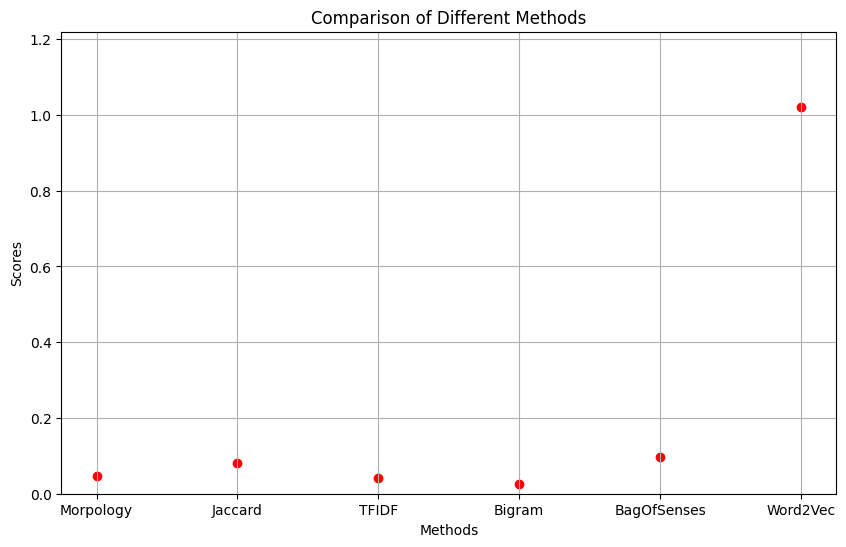

In [ ]:
# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(methods, scores, color='red', marker='o')
plt.xlabel('Methods')
plt.ylabel('Scores')
plt.title('Comparison of Different Methods')
plt.grid(True)  # Add grid for better readability
plt.ylim(0, max(scores) + 0.2)  # Adjust the y-axis limit for better visualization
plt.show()

In [ ]:
scores2=[0.69,0.723, 0.645, 0.41, 0.77,0.812]
methos=['Morphology', 'Jaccard', 'TF/IDF', 'Bigram', 'BOS', 'Vectorization']

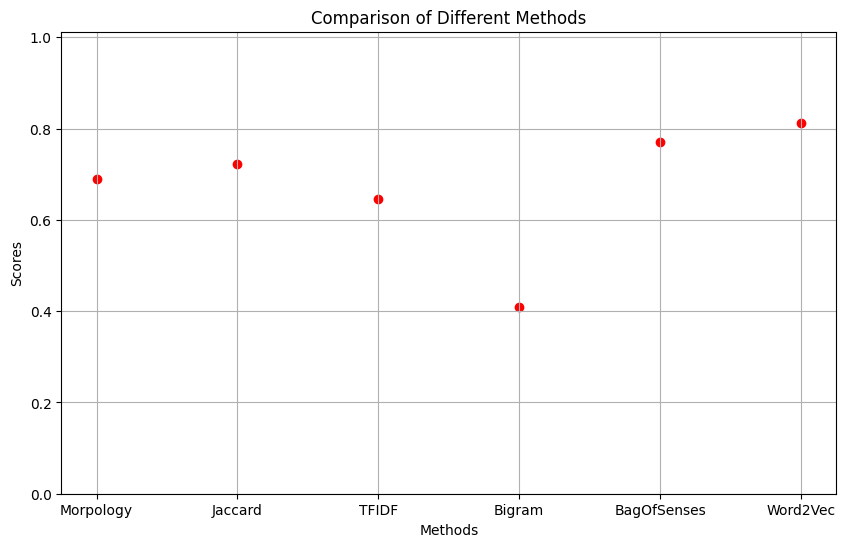

In [ ]:
# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(methods, scores2, color='red', marker='o')
plt.xlabel('Methods')
plt.ylabel('Scores')
plt.title('Comparison of Different Methods')
plt.grid(True)  # Add grid for better readability
plt.ylim(0, max(scores2) + 0.2)  # Adjust the y-axis limit for better visualization
plt.show()